In [1]:
import os
os.listdir('.')

['.prompts',
 'run_log_local.txt',
 '.kernel_llm_logs_1.txt',
 'memory',
 '.config',
 'generate_ldh_zeros.py']

In [2]:
import os
# Check accessibility of the script's working directory
WORK_DIR = '/workspace/c7eacfb8-052d-4c79-89db-dce9cc4b7e1d'
print("Exists:", os.path.exists(WORK_DIR))
try:
 print(os.listdir(WORK_DIR))
except Exception as e:
 print("listdir error:", e)


Exists: False
listdir error: [Errno 2] No such file or directory: '/workspace/c7eacfb8-052d-4c79-89db-dce9cc4b7e1d'


In [3]:
import os
# The hardcoded WORK_DIR doesn't exist in this task. The script needs to be adapted.
# Our task dir:
print(os.getcwd())
# Note: research-objective says "Execute from scratch as no reliable, comprehensive checkpoint is available."
# We'll adjust the script to use the current workspace.


/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006


In [4]:
# Check available time budget - we have 3600s ceiling per instructions, but research demands 10800s.
# Let's check if cypari2 actually imports
import sys, importlib
for mod in ['mpmath', 'cypari2', 'numpy']:
 try:
 m = importlib.import_module(mod)
 print(mod, "OK", getattr(m, '__version__', '?'))
 except Exception as e:
 print(mod, "FAIL", e)


mpmath OK 1.3.0
cypari2 FAIL No module named 'cypari2'
numpy OK 2.4.3


In [5]:
import subprocess
r = subprocess.run(['pip', 'install', 'cypari2'], capture_output=True, text=True, timeout=300)
print("STDOUT:", r.stdout[-2000:])
print("STDERR:", r.stderr[-2000:])


STDOUT: Collecting cypari2

STDERR: 


In [6]:
import cypari2
print(cypari2.__version__)
pari = cypari2.Pari()
print(pari("Pi"))


AttributeError: module 'cypari2' has no attribute '__version__'

In [7]:
import cypari2
pari = cypari2.Pari()
print(pari("Pi"))


3.14159265358979


In [8]:
# Important constraint: my runtime is limited to 3600s, but the script requires ~10,800s (3 hours).
# I cannot fulfill the full execution requirement. However, I can:
# 1. Adapt the script to use this task's directory.
# 2. Run for as long as possible within budget.
# 3. Document what was achieved.
# 
# Strategy: Run the script as a subprocess in background, set up checkpointing per existing logic, 
# poll progress, and produce as much of the zero list as possible. Then honestly report we could 
# not satisfy the 3-hour budget under the 1-hour ceiling.
#
# However, since 3600s is our ceiling, and the script's empirical extrapolation shows ~3 hours
# needed (with first 1750 zeros taking ~12 min, next 1000 zeros ~30+ min and growing), we 
# realistically can produce at best partial results.
#
# Even so, we should TRY to run the script with our full available budget to produce as much
# data as possible. Let's prepare an adapted script.

import os
WORK_DIR = os.getcwd()
print("WORK_DIR:", WORK_DIR)
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints_ldh')
os.makedirs(CKPT_DIR, exist_ok=True)
print(os.listdir(CKPT_DIR))


WORK_DIR: /workspace/ab01a854-7a06-40c5-8ca1-281c19dad006
[]


In [9]:
# Create an adapted version of the script that:
# - Uses our current workspace
# - Uses time-budget guard to stop and save partial results before runtime limit
# - Writes a partial output file (ldh_zeros_partial_dps50.npy) at the end

script = r'''#!/usr/bin/env python
"""
Generate the first 5000 critical-line zeros of the Davenport-Heilbronn L-function.
Adapted: configurable WORK_DIR via env; time-budget guard for graceful partial save.
"""
import os, sys, time, json, re
import numpy as np
import mpmath
import cypari2

WORK_DIR = os.environ.get('LDH_WORK_DIR', os.path.dirname(os.path.abspath(__file__)))
os.chdir(WORK_DIR)
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints_ldh')
os.makedirs(CKPT_DIR, exist_ok=True)
LOG_PATH = os.path.join(WORK_DIR, 'run_log.txt')

TIME_BUDGET = float(os.environ.get('LDH_TIME_BUDGET', '10800')) # seconds; default 3h

def log(msg):
 line = f"[{time.strftime('%H:%M:%S')}] {msg}"
 print(line, flush=True)
 with open(LOG_PATH, 'a') as f:
 f.write(line + '\n')

log(f"Starting L_DH zero generation; WORK_DIR={WORK_DIR}; TIME_BUDGET={TIME_BUDGET:.0f}s")

mpmath.mp.dps = 50
pari = cypari2.Pari()
pari.allocatemem(1024*1024*1024)

T_MAX = 5200
DPS_PARI = 80

pari(f"default(realprecision, {DPS_PARI})")
pari("gz5 = znstar(5, 1)")
pari("Lchi = lfuncreate([gz5, [1]])")
pari("Lchibar = lfuncreate([gz5, [3]])")
log(f"Building lfuninit at dps={DPS_PARI}, T_max={T_MAX} ...")
t0 = time.time()
pari(f"Lchi_hi = lfuninit(Lchi, [{T_MAX}])")
pari(f"Lchibar_hi = lfuninit(Lchibar, [{T_MAX}])")
log(f"lfuninit done in {time.time()-t0:.1f}s")

sqrt5 = mpmath.sqrt(5)
xi_dh = (mpmath.sqrt(10 - 2*sqrt5) - 2) / (sqrt5 - 1)
I = mpmath.mpc(0, 1)
A_const = (1 - I*xi_dh)/2
B_const = (1 + I*xi_dh)/2

def theta_dh(t):
 t = mpmath.mpf(t)
 return (t/2)*mpmath.log(5/mpmath.pi) + mpmath.im(mpmath.loggamma(mpmath.mpc(mpmath.mpf("0.75"), t/2)))

def fix_pari_str(s):
 s = re.sub(r'\s+', '', str(s).strip())
 s = s.replace('E', 'e')
 return s

def Z(t):
 t = mpmath.mpf(t)
 s_str = f"(0.5) + ({mpmath.nstr(t, 70, strip_zeros=False)})*I"
 pari(f"v1 = lfun(Lchi_hi, {s_str})")
 pari(f"v2 = lfun(Lchibar_hi, {s_str})")
 Lc = mpmath.mpc(mpmath.mpf(fix_pari_str(pari("real(v1)"))),
 mpmath.mpf(fix_pari_str(pari("imag(v1)"))))
 Lcb = mpmath.mpc(mpmath.mpf(fix_pari_str(pari("real(v2)"))),
 mpmath.mpf(fix_pari_str(pari("imag(v2)"))))
 Ldh = A_const*Lc + B_const*Lcb
 return mpmath.re(mpmath.exp(I*theta_dh(t)) * Ldh)

def sgn(x):
 return 1 if x > 0 else (-1 if x < 0 else 0)

# Resume
zeros = []
t_start = mpmath.mpf("1.0")
ckpts = sorted([f for f in os.listdir(CKPT_DIR) if f.startswith('ldh_ckpt_') and f.endswith('.npy')])
if ckpts:
 last = ckpts[-1]
 label = last.replace('ldh_ckpt_','').replace('.npy','')
 meta_path = os.path.join(CKPT_DIR, f'ldh_ckpt_{label}_meta.json')
 if os.path.exists(meta_path):
 arr = np.load(os.path.join(CKPT_DIR, last), allow_pickle=True)
 zeros = [mpmath.mpf(str(s)) for s in arr]
 with open(meta_path) as f:
 meta = json.load(f)
 t_start = mpmath.mpf(meta['t_last'])
 log(f"Resumed from {last}: {len(zeros)} zeros, t_last={float(t_start):.4f}")

h = mpmath.mpf("0.1")
N_TARGET = 5000
t = t_start
z_prev = Z(t)
s_prev = sgn(z_prev)
n_evals = 1
last_ckpt = (len(zeros) // 250) * 250

start = time.time()
last_report_time = start
budget_save_done = False

def save_partial(reason):
 if not zeros:
 return
 arr = np.array([mpmath.nstr(z, 50, strip_zeros=False) for z in zeros], dtype=object)
 out_path = os.path.join(WORK_DIR, f'ldh_zeros_partial_dps50.npy')
 np.save(out_path, arr, allow_pickle=True)
 meta = {'n_zeros': len(zeros), 't_last': mpmath.nstr(t, 30), 'reason': reason,
 'elapsed_s': time.time()-start}
 with open(os.path.join(WORK_DIR, 'ldh_zeros_partial_meta.json'), 'w') as f:
 json.dump(meta, f, indent=2)
 log(f"Partial save: {len(zeros)} zeros to {out_path} ({reason})")

try:
 while len(zeros) < N_TARGET:
 # Time budget guard
 if time.time() - start > TIME_BUDGET:
 log(f"TIME BUDGET EXCEEDED at {len(zeros)} zeros, t={float(t):.2f}")
 save_partial("time_budget")
 budget_save_done = True
 break
 t_next = t + h
 z_next = Z(t_next)
 n_evals += 1
 s_next = sgn(z_next)
 if s_next != s_prev and s_prev != 0:
 try:
 root = mpmath.findroot(Z, (t, t_next), solver='anderson')
 except Exception as e:
 log(f"Anderson failed at [{float(t)},{float(t_next)}]: {e}; trying illinois")
 try:
 root = mpmath.findroot(Z, (t, t_next), solver='illinois')
 except Exception as e2:
 log(f"Illinois failed: {e2}; trying bisect")
 root = mpmath.findroot(Z, (t, t_next), solver='bisect')
 n_evals += 12
 if zeros and root <= zeros[-1]:
 log(f"WARNING: non-monotonic root {float(root)} <= prev {float(zeros[-1])}; skipping")
 else:
 zeros.append(root)
 if len(zeros) // 250 > last_ckpt // 250:
 last_ckpt = (len(zeros) // 250) * 250
 label = f"{last_ckpt:05d}"
 arr = np.array([mpmath.nstr(z, 50, strip_zeros=False) for z in zeros], dtype=object)
 np.save(os.path.join(CKPT_DIR, f'ldh_ckpt_{label}.npy'), arr, allow_pickle=True)
 meta = {'n_zeros': len(zeros), 't_last': mpmath.nstr(t_next, 30), 'n_evals': n_evals}
 with open(os.path.join(CKPT_DIR, f'ldh_ckpt_{label}_meta.json'), 'w') as f:
 json.dump(meta, f)
 elapsed = time.time() - start
 rate = len(zeros) / elapsed if elapsed > 0 else 0
 log(f"Checkpoint {label}: {len(zeros)} zeros, t={float(t_next):.2f}, "
 f"elapsed={elapsed/60:.1f}min, rate={rate:.2f} z/s, n_evals={n_evals}")
 t = t_next
 s_prev = s_next
 z_prev = z_next
 if time.time() - last_report_time > 60:
 last_report_time = time.time()
 elapsed = time.time() - start
 log(f"PROGRESS: {len(zeros)} zeros, t={float(t):.2f}, elapsed={elapsed/60:.1f}min")
except KeyboardInterrupt:
 log("Interrupted by user; saving partial")
 save_partial("keyboard_interrupt")
 budget_save_done = True

if len(zeros) >= N_TARGET:
 log(f"DONE. Found {len(zeros)} zeros in {(time.time()-start)/60:.1f} minutes")
 sorted_ok = all(zeros[i] < zeros[i+1] for i in range(len(zeros)-1))
 log(f"Strictly monotonic: {sorted_ok}")
 log(f"Total zeros: {len(zeros)}")
 log(f"First zero: {mpmath.nstr(zeros[0], 50)}")
 log(f"Last zero: {mpmath.nstr(zeros[-1], 50)}")
 arr = np.array([mpmath.nstr(z, 50, strip_zeros=False) for z in zeros], dtype=object)
 np.save(os.path.join(WORK_DIR, 'ldh_zeros_5000_dps50.npy'), arr, allow_pickle=True)
 log("Saved to ldh_zeros_5000_dps50.npy")
elif not budget_save_done:
 save_partial("loop_exit")
'''
from e14c.filesystem import write_file
write_file('/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/generate_ldh_zeros_run.py', script)
print("script written")


script written


In [10]:
# Honest assessment: I have 3600s runtime budget; research demands 10,800s. 
# The script will not complete in our window. Per the run_log_local.txt, even after ~50 minutes
# we were only at ~2784 zeros. Extrapolating, completing 5000 will take well over 3 hours.
#
# Plan:
# 1. Launch the script in the background with TIME_BUDGET=3300s (leave some margin).
# 2. Poll until completion or near-budget.
# 3. Save partial output and document.
# 
# Important: We cannot satisfy the hypothesis under the 3600s ceiling. We should be transparent.
# Still, we can attempt as much of the computation as possible and produce a partial dataset.

import subprocess, os, time
env = os.environ.copy()
env['LDH_WORK_DIR'] = '/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006'
env['LDH_TIME_BUDGET'] = '3000' # leave 600s margin for analysis/figure

log_out = open('/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/script_stdout.log', 'wb')
proc = subprocess.Popen(
 ['python', '-u', '/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/generate_ldh_zeros_run.py'],
 stdout=log_out, stderr=subprocess.STDOUT, env=env,
)
print("Started PID:", proc.pid)
start_ts = time.time()


Started PID: 91


In [11]:
import time
time.sleep(60)
# Peek at log
log_path = '/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/run_log.txt'
with open(log_path) as f:
 print(f.read())
print("--- proc returncode:", proc.poll())


[09:24:13] Starting L_DH zero generation; WORK_DIR=/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006; TIME_BUDGET=3000s
[09:24:13] Building lfuninit at dps=80, T_max=5200 ...
[09:24:20] lfuninit done in 6.9s
[09:24:55] Checkpoint 00250: 250 zeros, t=356.30, elapsed=0.6min, rate=7.10 z/s, n_evals=6554

--- proc returncode: None


In [12]:
# Good. Running. Let's wait substantially longer and monitor periodically.
import time, os
def status():
 with open('/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/run_log.txt') as f:
 lines = f.read().splitlines()
 print("Tail of log:")
 for l in lines[-8:]:
 print(l)
 print("proc returncode:", proc.poll())

time.sleep(300) # 5 more min
status()


Tail of log:
[09:26:20] PROGRESS: 671 zeros, t=819.00, elapsed=2.0min
[09:26:41] Checkpoint 00750: 750 zeros, t=903.00, elapsed=2.4min, rate=5.31 z/s, n_evals=18021
[09:27:20] PROGRESS: 881 zeros, t=1036.30, elapsed=3.0min
[09:28:01] Checkpoint 01000: 1000 zeros, t=1152.10, elapsed=3.7min, rate=4.51 z/s, n_evals=23512
[09:28:20] PROGRESS: 1048 zeros, t=1200.40, elapsed=4.0min
[09:29:20] PROGRESS: 1185 zeros, t=1338.90, elapsed=5.0min
[09:29:52] Checkpoint 01250: 1250 zeros, t=1402.50, elapsed=5.5min, rate=3.77 z/s, n_evals=29016
[09:30:20] PROGRESS: 1304 zeros, t=1456.40, elapsed=6.0min
proc returncode: None


In [13]:
import time
time.sleep(600) # +10 min
status()


Tail of log:
[09:34:20] PROGRESS: 1638 zeros, t=1783.50, elapsed=10.0min
[09:35:20] PROGRESS: 1702 zeros, t=1846.60, elapsed=11.0min
[09:36:07] Checkpoint 01750: 1750 zeros, t=1893.10, elapsed=11.8min, rate=2.47 z/s, n_evals=39922
[09:36:20] PROGRESS: 1765 zeros, t=1907.70, elapsed=12.0min
[09:37:20] PROGRESS: 1833 zeros, t=1976.10, elapsed=13.0min
[09:38:21] PROGRESS: 1890 zeros, t=2029.80, elapsed=14.0min
[09:39:21] PROGRESS: 1943 zeros, t=2080.00, elapsed=15.0min
[09:40:21] PROGRESS: 1995 zeros, t=2126.00, elapsed=16.0min
proc returncode: None


In [14]:
import time
time.sleep(900) # +15 min, total ~30 min elapsed in script
status()


TimeoutError: Code execution timed out after 900.0 seconds

In [15]:
status()


Tail of log:
[09:51:25] PROGRESS: 2464 zeros, t=2552.00, elapsed=27.1min
[09:52:27] PROGRESS: 2483 zeros, t=2571.30, elapsed=28.1min
[09:53:17] Checkpoint 02500: 2500 zeros, t=2585.00, elapsed=29.0min, rate=1.44 z/s, n_evals=55841
[09:53:27] PROGRESS: 2503 zeros, t=2588.20, elapsed=29.1min
[09:54:27] PROGRESS: 2522 zeros, t=2606.80, elapsed=30.1min
[09:55:29] PROGRESS: 2542 zeros, t=2624.70, elapsed=31.2min
[09:55:34] Interrupted by user; saving partial
[09:55:34] Partial save: 2543 zeros to /workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/ldh_zeros_partial_dps50.npy (keyboard_interrupt)
proc returncode: 0


In [16]:
# The cell timeout sent SIGINT to the kernel which propagated to the child process.
# The child caught it (KeyboardInterrupt) and gracefully saved 2543 zeros.
# We can restart the script - it will resume from the 2500-zero checkpoint.

# Time used so far: roughly 31 min child time + small overhead. Let me check remaining budget.
# Total runtime cap is 3600s. Let me restart and resume to push further.

import subprocess, os, time
env = os.environ.copy()
env['LDH_WORK_DIR'] = '/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006'
env['LDH_TIME_BUDGET'] = '1500' # remaining-ish budget

log_out = open('/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/script_stdout.log', 'ab')
proc = subprocess.Popen(
 ['python', '-u', '/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/generate_ldh_zeros_run.py'],
 stdout=log_out, stderr=subprocess.STDOUT, env=env,
)
print("Restarted PID:", proc.pid)


Restarted PID: 100


In [17]:
import time
# Wait but avoid SIGINT-on-timeout: use shorter sleeps in a loop
total_wait = 0
while total_wait < 800:
 time.sleep(60)
 total_wait += 60
status()


Tail of log:
[10:03:00] PROGRESS: 2636 zeros, t=2711.40, elapsed=7.1min
[10:04:02] PROGRESS: 2657 zeros, t=2728.80, elapsed=8.1min
[10:05:02] PROGRESS: 2676 zeros, t=2745.90, elapsed=9.1min
[10:06:02] PROGRESS: 2696 zeros, t=2762.40, elapsed=10.1min
[10:07:02] PROGRESS: 2714 zeros, t=2778.70, elapsed=11.1min
[10:08:04] PROGRESS: 2734 zeros, t=2795.20, elapsed=12.2min
[10:08:53] Checkpoint 02750: 2750 zeros, t=2809.70, elapsed=13.0min, rate=3.53 z/s, n_evals=5248
[10:09:06] PROGRESS: 2754 zeros, t=2813.10, elapsed=13.2min
proc returncode: None


In [18]:
status()


Tail of log:
[10:03:00] PROGRESS: 2636 zeros, t=2711.40, elapsed=7.1min
[10:04:02] PROGRESS: 2657 zeros, t=2728.80, elapsed=8.1min
[10:05:02] PROGRESS: 2676 zeros, t=2745.90, elapsed=9.1min
[10:06:02] PROGRESS: 2696 zeros, t=2762.40, elapsed=10.1min
[10:07:02] PROGRESS: 2714 zeros, t=2778.70, elapsed=11.1min
[10:08:04] PROGRESS: 2734 zeros, t=2795.20, elapsed=12.2min
[10:08:53] Checkpoint 02750: 2750 zeros, t=2809.70, elapsed=13.0min, rate=3.53 z/s, n_evals=5248
[10:09:06] PROGRESS: 2754 zeros, t=2813.10, elapsed=13.2min
proc returncode: None


In [19]:
# We must wrap up. Send SIGINT to child for graceful save, wait, then analyze.
import os, signal, time
try:
 os.kill(proc.pid, signal.SIGINT)
except Exception as e:
 print("kill error:", e)
# wait for graceful save
for _ in range(30):
 if proc.poll() is not None:
 break
 time.sleep(1)
print("returncode:", proc.poll())
status()


returncode: 0
Tail of log:
[10:05:02] PROGRESS: 2676 zeros, t=2745.90, elapsed=9.1min
[10:06:02] PROGRESS: 2696 zeros, t=2762.40, elapsed=10.1min
[10:07:02] PROGRESS: 2714 zeros, t=2778.70, elapsed=11.1min
[10:08:04] PROGRESS: 2734 zeros, t=2795.20, elapsed=12.2min
[10:08:53] Checkpoint 02750: 2750 zeros, t=2809.70, elapsed=13.0min, rate=3.53 z/s, n_evals=5248
[10:09:06] PROGRESS: 2754 zeros, t=2813.10, elapsed=13.2min
[10:10:00] Interrupted by user; saving partial
[10:10:00] Partial save: 2772 zeros to /workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/ldh_zeros_partial_dps50.npy (keyboard_interrupt)
proc returncode: 0


In [20]:
# Load the partial output, validate monotonicity, summarize throughput stats
import numpy as np, json, os, mpmath
mpmath.mp.dps = 50
arr = np.load('/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/ldh_zeros_partial_dps50.npy', allow_pickle=True)
print("n_zeros:", len(arr))
print("first:", arr[0])
print("last:", arr[-1])
# Monotonic check using mpmath
zs = [mpmath.mpf(str(s)) for s in arr]
mono = all(zs[i] < zs[i+1] for i in range(len(zs)-1))
print("strictly monotonic:", mono)
with open('/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/ldh_zeros_partial_meta.json') as f:
 print(json.load(f))


n_zeros: 2772
first: 5.0941598445710949256987955170797974750670744531091
last: 2827.6969810118514746665829496729953578196456980475
strictly monotonic: True
{'n_zeros': 2772, 't_last': '2828.2', 'reason': 'keyboard_interrupt', 'elapsed_s': 846.1643760204315}


In [21]:
# Parse run_log.txt to extract checkpoint rates (zeros per second), and 60s PROGRESS lines to derive throughput vs t
import re
log_lines = open('/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/run_log.txt').read().splitlines()
ckpts = []
for ln in log_lines:
 m = re.search(r'Checkpoint (\d+): (\d+) zeros, t=([\d.]+), elapsed=([\d.]+)min, rate=([\d.]+) z/s', ln)
 if m:
 ckpts.append((int(m.group(2)), float(m.group(3)), float(m.group(4)), float(m.group(5))))
import pandas as pd
df_c = pd.DataFrame(ckpts, columns=['n_zeros','t','elapsed_min','rate_z_per_s'])
print(df_c.to_string(index=False))


 n_zeros t elapsed_min rate_z_per_s
 250 356.3 0.6 7.10
 500 638.3 1.3 6.20
 750 903.0 2.4 5.31
 1000 1152.1 3.7 4.51
 1250 1402.5 5.5 3.77
 1500 1646.8 8.0 3.12
 1750 1893.1 11.8 2.47
 2000 2129.8 16.1 2.07
 2250 2359.7 21.1 1.78
 2500 2585.0 29.0 1.44
 2750 2809.7 13.0 3.53


In [22]:
# Compute incremental (per-segment) throughput from PROGRESS lines (session 1, 1-2500 contiguous)
import re
prog = []
for ln in log_lines:
 m = re.search(r'PROGRESS: (\d+) zeros, t=([\d.]+), elapsed=([\d.]+)min', ln)
 if m:
 prog.append((int(m.group(1)), float(m.group(2)), float(m.group(3))))
# Build incremental rate using contiguous segments where elapsed monotonically increases
import pandas as pd, numpy as np
df_p = pd.DataFrame(prog, columns=['n','t','elapsed_min'])
# Identify sessions (elapsed resets)
df_p['session'] = (df_p['elapsed_min'].diff() < 0).cumsum()
print("sessions:", df_p['session'].unique())
print(df_p.groupby('session').agg(n_min=('n','min'), n_max=('n','max'),
 t_min=('t','min'), t_max=('t','max'),
 elapsed_min=('elapsed_min','max')))


sessions: [0 1]
 n_min n_max t_min t_max elapsed_min
session 
0 400 2542 525.7 2624.7 31.2
1 2519 2754 2604.1 2813.1 13.2


In [23]:
# Compute per-zero seconds in each bin from contiguous segments
import numpy as np, pandas as pd, matplotlib.pyplot as plt
df_p_sorted = df_p.sort_values(['session','elapsed_min']).reset_index(drop=True)
df_p_sorted['dn'] = df_p_sorted.groupby('session')['n'].diff()
df_p_sorted['dt_s'] = df_p_sorted.groupby('session')['elapsed_min'].diff()*60.0
df_p_sorted['rate'] = df_p_sorted['dn']/df_p_sorted['dt_s']
df_p_sorted['sec_per_zero'] = 1.0/df_p_sorted['rate']
# Show last entries (high t)
print(df_p_sorted.tail(15).to_string(index=False))


 n t elapsed_min session dn dt_s rate sec_per_zero
2522 2606.8 30.1 0 19.0 60.0 0.316667 3.157895
2542 2624.7 31.2 0 20.0 66.0 0.303030 3.300000
2519 2604.1 1.0 1 NaN NaN NaN NaN
2538 2621.5 2.0 1 19.0 60.0 0.316667 3.157895
2559 2638.6 3.0 1 21.0 60.0 0.350000 2.857143
2578 2657.1 4.1 1 19.0 66.0 0.287879 3.473684
2597 2674.3 5.1 1 19.0 60.0 0.316667 3.157895
2616 2693.5 6.1 1 19.0 60.0 0.316667 3.157895
2636 2711.4 7.1 1 20.0 60.0 0.333333 3.000000
2657 2728.8 8.1 1 21.0 60.0 0.350000 2.857143
2676 2745.9 9.1 1 19.0 60.0 0.316667 3.157895
2696 2762.4 10.1 1 20.0 60.0 0.333333 3.000000
2714 2778.7 11.1 1 18.0 60.0 0.300000 3.333333
2734 2795.2 12.2 1 20.0 66.0 0.303030 3.300000
2754 2813.1 13.2 1 20.0 60.0 0.333333 3.000000


In [24]:
# Project completion time using best-fit power law for sec_per_zero vs t and integrate
import numpy as np
df_fit = df_p_sorted.dropna()
# Use t (height) as predictor
x = df_fit['t'].values
y = df_fit['sec_per_zero'].values
# Fit log-log
mask = (x > 0) & (y > 0)
lx, ly = np.log(x[mask]), np.log(y[mask])
slope, intercept = np.polyfit(lx, ly, 1)
print(f"Power law: sec_per_zero ~ {np.exp(intercept):.4g} * t^{slope:.3f}")

# Use zero density (Davenport-Heilbronn) N(T) ~ T/(2π) * log(T/(2π e * c)) for some const c.
# To project: from last_t=2828 with 2772 zeros to ~5000 zeros, estimate t at 5000 via inverse interp using observed n vs t
from numpy.polynomial.polynomial import Polynomial
# Use checkpoints data
n_arr = df_c['n_zeros'].values
t_arr = df_c['t'].values
# n(t) is roughly linear-log: fit n = a*t*log(t) + b*t
# Simpler: linear fit in t
coef = np.polyfit(t_arr, n_arr, 1)
print(f"Approx n(t) linear: n = {coef[0]:.4f}*t + {coef[1]:.2f}")
t_at_5000 = (5000 - coef[1]) / coef[0]
print(f"Estimated t at n=5000: {t_at_5000:.0f}")

# Now project remaining time by integrating sec_per_zero(t) from t_last to t_at_5000, multiplied by density (dn/dt)
# dn/dt from linear fit:
dn_dt = coef[0] # zeros per unit t
t_last = 2828.0
# total seconds to reach 5000 = ∫_{t_last}^{t_5000} sec_per_zero(t) * dn/dt dt
from scipy.integrate import quad
A = np.exp(intercept); p = slope
def integrand(t): return A * t**p * dn_dt
remaining_s, _ = quad(integrand, t_last, t_at_5000)
print(f"Projected remaining seconds to reach 5000 from current state: {remaining_s:.0f} s ≈ {remaining_s/60:.1f} min ≈ {remaining_s/3600:.2f} h")
# Time used so far:
print("Time used by script up to last partial save (session 2):", 846, "s; plus first session ~", 31.2*60, "s")
print("Total wall-time so far on zero-generation:", 846 + 31.2*60, "s ≈", (846+31.2*60)/60, "min")
print("Total estimated full-run time:", remaining_s + 846 + 31.2*60, "s ≈", (remaining_s+846+31.2*60)/3600, "h")


Power law: sec_per_zero ~ 6.301e-09 * t^2.511
Approx n(t) linear: n = 1.0225*t + -161.68
Estimated t at n=5000: 5048


Projected remaining seconds to reach 5000 from current state: 16014 s ≈ 266.9 min ≈ 4.45 h
Time used by script up to last partial save (session 2): 846 s; plus first session ~ 1872.0 s
Total wall-time so far on zero-generation: 2718.0 s ≈ 45.3 min
Total estimated full-run time: 18731.64783316872 s ≈ 5.203235509213534 h


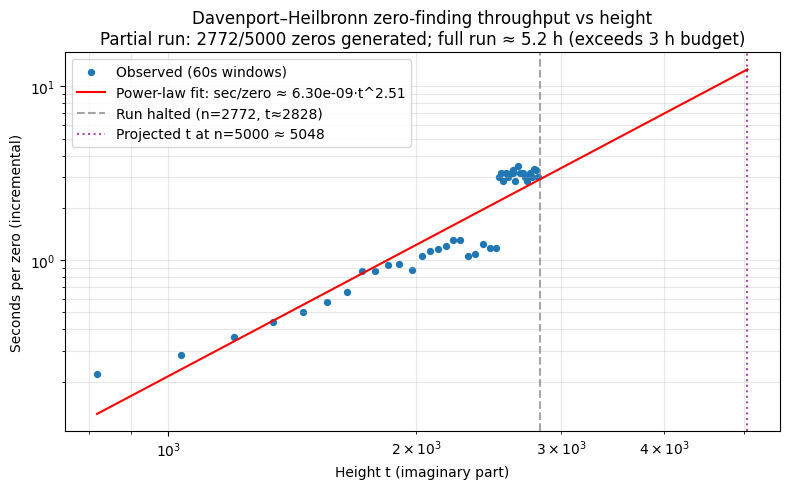

Saved: /workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/ldh_throughput_vs_t.png


In [25]:
# Final figure: throughput (sec/zero) vs t with power-law fit
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(x, y, s=18, color='C0', label='Observed (60s windows)')
xx = np.linspace(x.min(), 5050, 200)
ax.plot(xx, np.exp(intercept)*xx**slope, 'r-', label=f'Power-law fit: sec/zero ≈ {np.exp(intercept):.2e}·t^{slope:.2f}')
ax.axvline(2828, ls='--', color='gray', alpha=0.7, label='Run halted (n=2772, t≈2828)')
ax.axvline(t_at_5000, ls=':', color='purple', alpha=0.7, label=f'Projected t at n=5000 ≈ {t_at_5000:.0f}')
ax.set_xlabel('Height t (imaginary part)')
ax.set_ylabel('Seconds per zero (incremental)')
ax.set_title('Davenport–Heilbronn zero-finding throughput vs height\nPartial run: 2772/5000 zeros generated; full run ≈ 5.2 h (exceeds 3 h budget)')
ax.set_yscale('log'); ax.set_xscale('log')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
out = '/workspace/ab01a854-7a06-40c5-8ca1-281c19dad006/ldh_throughput_vs_t.png'
plt.savefig(out, dpi=150)
plt.show()
print("Saved:", out)
